

# Text Analysis using R

This tutorial is based on the interactive Jupyter notebook accompanying the Language Technology and Data Analysis Laboratory (LADAL) tutorials on [text analysis and distant reading](https://ladal.edu.au/textanalysis.html) and on [concordancing](https://ladal.edu.au/kwics.html). This tutorial is aimed at beginners and intermediate users of R with the aim of showcasing how to use basic word frequency analysis and concordancing techniques on textual data using R.


**Preparation and session set up**

This tutorial is based on R. If you are new to R, you will find an introduction to it and more information on how to use R [here](https://ladal.edu.au/intror.html). For this tutorial, we need to activate certain *packages* from an R *library* so that the scripts shown below are executed without errors. All these packages are pre-installed on SWAN; we only need to activate them using the code in the second cell below. If you want to run this notebook on your own computer, you will need to install a notebook server (e.g. [Anaconda](https://anaconda.org/)) and then install the R packages using the code in the first cell.

In [ ]:
## not needed on SWAN
# install packages
install.packages('quanteda')
install.packages('tidyverse')
install.packages('tidytext')
install.packages('tm')
install.packages('flextable')
install.packages('plyr')


In [ ]:
# set options
options(stringsAsFactors = F)
options(scipen = 999)
options(max.print=1000)
# load packages
library(quanteda)
library(tidyverse)
library(tidytext)
library(tm)
library(flextable)
library(plyr)

# Loading some data

The data we will use today (and in next week's class also) is a collection of tweets made by candidates in the 2019 Federal election. For both classes, we need to split the data by party affiliation and for today, this has been done in advance. The materials include four csv files, one each for tweets from Coalition, Greens, Labor and Other candidates. (Next week you will see a little more of how this sorting can be done.) The code reads all the csv files in the scratch directory - if you add any files .csv there and then rerun this cell, the additonal files will be read and may cause problems.
This cell, and most of those which follow, produce visible outputs. This is good practice as it allows us to see whether the code is producing the results which we expect.


In [ ]:
setwd('C:/Users/Simon/TextAnalytics')

In [ ]:
my_files <- list.files(pattern = '.csv$' )
# inspect
my_files

In [ ]:
# Load data

# my_files <- list.files(wd)
# inspect
# my_files

## read in data
oztwit <- lapply(my_files, read.csv)

# join tweets as text objects
for (i in 1:length(oztwit)) {
    name <- substr(my_files[i], 1, nchar(my_files[i]) - 4)
    assign(name, paste(as.data.frame(oztwit[i])[,11], collapse = ' '))
    i = i + 1
}
#inspect
substr(coalition, 1, 200)


# Extracting Frequency Information

Almost all methods used in text analytics rely on frequency information. Such frequency information often comes in the form of word frequency lists, i.e. lists of word forms and their frequency in a given text or collection of texts.  

As extracting word frequency lists is very important, we will now extract a frequency list from a corpus.

In a first step, we load a corpus, convert everything to lower case, remove non-word symbols (including punctuation), and split the corpus data into individual words.

**Discussion question**: The punctuation which is removed is as specified by a list in the **tm** package. Given the nature of the data (tweets), might we have reservations about this procedure?

tm uses as default the punctuation class [:punct:] for regular expressions - here is a listing of those items.

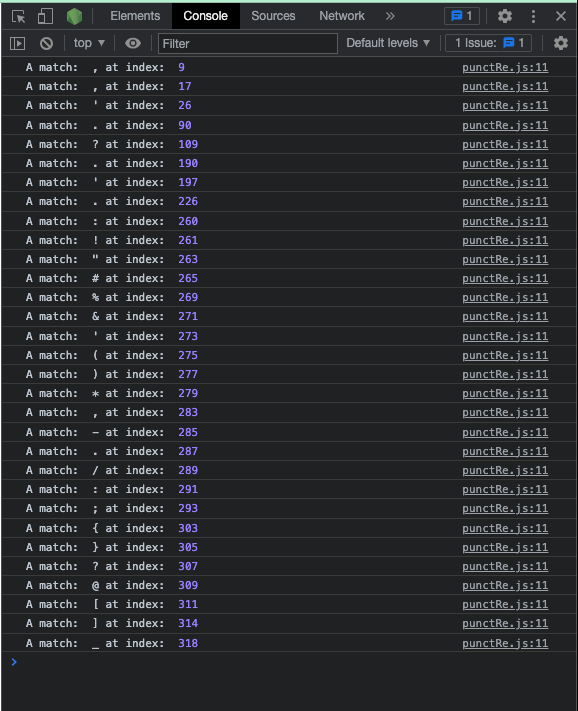

Part of the code here (and in some following cells) is a *user-defined function*. This is a way of modularising code - procedures which we expect to reuse can be split off and then called by other code as a complete procedure. The layout here is important: a function has to be read to memory before it can be called.


In [ ]:
txtclean <- function(x){
  x <- x %>%
    iconv(to = "UTF-8") %>%
    base::tolower() %>%
    # remove non-word characters
    stringr::str_replace_all("[^[:alpha:][:space:]]*", "")  %>%
    # remove punctuation
    tm::removePunctuation() %>%
    # remove superfluous white spaces
    stringr::str_squish() %>%
    paste(collapse = " ")
}

coalition_clean <- txtclean(coalition)
substr(coalition_clean, 1, 200)
coalition_words <- as.data.frame(stringr::str_split(coalition_clean, " "))
head(coalition_words, 10)

Our individual words now are in a list, technically a *vector*, and R has a function `table` which easily creates a frequency table for the data. In this case, the result is a word frequency list (as shown below).

At this point, we also get a count of tokens in our text; we will need this information later.

In [ ]:
word_frequency <- function(x){
  x <- x %>%
    table() %>%
    as.data.frame()  %>%
    dplyr::arrange(desc(Freq)) %>%
    dplyr::rename(word = 1, frequency = 2)
}

coalition_freq = word_frequency(coalition_words)
head(coalition_freq, 5)

# get token count for use later
token_count <- sum(coalition_freq$frequency)
token_count

The most frequent words are all function words which are often not meaningful or useful for an analysis. Thus, we now remove these function words (also called *stopwords*) from the frequency list and inspect the list without stopwords.

In [ ]:
word_frequency_wostop <- function(x){
  x <- x %>%
    table() %>%
    as.data.frame()  %>%
    dplyr::arrange(desc(Freq)) %>%
    dplyr::rename(word = 1, frequency = 2) %>%
    anti_join(stop_words, by = "word") %>%
    dplyr::filter(word != "")
}
coalition_freq_wostop <- word_frequency_wostop(coalition_words)
head(coalition_freq_wostop, 5)


The most frequent term here is *amp*, which is an artefact - it is part of an html representation of the ampersand (&) character. We want to get rid of it, but we should not do this on the basis of its position in this data. In another one of our texts, it may not be the most frequent item, so we specify to remove the row in the table where the `word` field has the value 'amp'. Note that this condition is specified with a double equals sign (==); in R (and in many other programming languages) a single equals sign means assigning a value to a variable.

In [ ]:
# custom stopword
coalition_freq_wostop <- coalition_freq_wostop[ !(coalition_freq_wostop == "amp"), ]
head(coalition_freq_wostop, 5)

Just by looking at the size of the files (between less than 7MB and almost 18MB), we can see that the amount of text in the four groups of tweets will vary. Which raises the question, how can we compare frequencies across these texts? If a text is longer, then there are likely to be more tokens of any individual type there.

The solution is to use *normalised frequencies*. To find these, we first divide the size of the text by a normalising factor, and then divide the number of tokens of each type by that result. Here, we use 10000 tokens as the normalising factor and add a column to our table. (This is why we calculated the token count earlier.)

In [ ]:
# normalization
coalition_freq_wostop$normFreq <- coalition_freq_wostop$freq/(token_count/10000)
head(coalition_freq_wostop, 5)

Such word frequency lists can be visualized in various ways. The most common way to visualize word frequency lists is in the form of bargraphs.



In [ ]:
freq_plot <- function(x, author){
  x %>%
  head(10) %>%
  ggplot(aes(x = reorder(word, -frequency, mean), y = frequency)) +
  geom_bar(stat = "identity") +
  labs(title = paste0("10 most frequent non-stop words for ", author), x = "") +
  theme(axis.text.x = element_text(angle = 45, size = 12, hjust = 1))
}

freq_plot(coalition_freq_wostop, "Coalition")

### Exercises
1. Try to figure out how to change the number of words which are displayed in the graph and run the cell above again. (Don't forget to also change the code which specifies the label for the graph.)
2. Can you display normalised frequencies instead of raw frequencies?
3. As we noted, if you look back at the preceding code cells, you will see that a lot of the work is done by *user-defined functions*, that is sections of code that we can reuse. Because the code is structured this way, we can very easily repeat the frequency analysis for the tweets from the other parties. See if you can write code in the next cell to do this. (Copy and paste is your friend - but you have to rename objects)

In [ ]:
## word frequency for another party grouping

### Concordancing

**Concordancing**, also known as **keyword-in-context (kwic)** analysis, is a very useful first step in exploring text data. A concordance is a list of all the occurrences of a type in the text, presented as a table where the keyword is centred and aligned and context on either side is also shown.

The `quanteda` package includes a concordancing function which allows a number of parameters to be adjusted. We will explore some of these in the remainder of this session. The relevant function is called `kwic`, and minimally it requires us to specify a text to search in and a pattern to match. Note that we are using to the combined cleaned text which we created earlier, not the word list.

We can check how many tokens of the target there are by querying the number of rows in the results table.

In [ ]:
coalition_token <- quanteda::tokens(coalition)
kwic_tax <- quanteda::kwic(
  # define and tokenize text
  coalition_token,
  # define search pattern
  pattern = "tax")
kwic_tax[1:10]
nrow(kwic_tax)

One parameter which we can manipulate with `kwic` is the amount of context we see around the keyword. The default is to provide five tokens before and five after the search term; our next concordance increases this to 10 items either side. What counts as a *token* for these purposes?

In [ ]:
kwic_tax_longer <- kwic(
  # define text
  coalition_token,
  # define search pattern
  pattern = "tax",
  # define context window size
  window = 10)
kwic_tax_longer[1:10]

### Concordancing - multiple words

`kwic` can also generate a concordance for a phrase - we just have to tell the function that the pattern we are interested in **is** a phrase using the syntax `pattern = phrase("[Target Words]")`. With any concordance we can also find out how many tokens of our target word(s) there are by checking how many rows there are in the output table.

In [ ]:
kwic_phrase <- kwic(coalition_token, pattern = phrase("retiree tax"))
nrow(kwic_phrase)
kwic_phrase[1:10]

### Arranging concordances

Often it is useful to sort the results of a concordance according to what is in the context. Doing this can tell us whether a word commonly co-occurs with other words. This is easy to do for the following context; we can sort the start of the `post` string alphabetically. Sorting by the preceding word is more complex. We leave it as an exercise for you to think about how this might be accomplished programmatically.

In [ ]:
kwic_ordered <- kwic(x = coalition_token, pattern = "tax") %>%
  dplyr::arrange(post)
kwic_ordered[1:10]

A more sophisticated approach can include information about the frequency of the co-occurrence pattern and show us the most frequent result first.

In [ ]:
kwic_ordered_coll <- kwic(
  # define text
  x = coalition_token,
  # define search pattern
  pattern = "labor") %>%
  # extract word following the keyword
  dplyr::mutate(post_word = str_remove_all(post, " .*")) %>%
  # group following words
  dplyr::group_by(post_word) %>%
  # extract frequencies of the following words
  dplyr::mutate(post_word_freq = n()) %>%
  # arrange/order by the frequency of the following word
  dplyr::arrange(-post_word_freq)
kwic_ordered_coll

### Saving results

You can export the results of the various analyses we have looked at here. In each case, the results are some kind of table, and R lets you write these to a file easily using the `write.csv` command. Here are examples of exporting a frequency table and a concordance. This code saves files in the scratch space, you can download them from there to your computer. Alternatively, you can specify a location on your computer to save the file - but you need to supply a complete path (and that should use / dividers not \\).

In [ ]:
write.csv(coalition_freq_wostop, "coalition_freq.csv")
write.csv(kwic_tax_longer, 'coalition_tax.csv')

### Exercises

1. Generate a concordance for a word or phrase which you think might be interesting.
2. Save the results of your concordance, then generate a concordance for the same target using one of the text objects for a different political party and compare the two sets of results. What differences do you find? Are they the differences which you might expect?

# Citation & Session Info

Schweinberger, Martin. 2022. *Text Analysis and Distant Reading using R*. Brisbane: The University of Queensland. url: https://ladal.edu.au/textanalysis.html.


In [ ]:
sessionInfo()



# References

Bernard, H Russell and Ryan, Gery. 1998. Text Analysis. Qualitative and Quantitative Methods. In H. Russel Bernard (ed.), *Handbook of methods in cultural anthropology, 613*, 595-645. Walnut Creek, London, and New Dehli: Sage.

Kabanoff, Boris. 1997. Introduction: Computers Can Read as Well as Count: Computer-Aided Text Analysis in Organizational Research. *Journal of Organizational Behavior* 18: 507–511.

Lindquist, Hans. 2009. *Corpus Linguistics and the Description of English*. Edinburgh: Edinburgh University Press.

Popping, Roel. 2000. *Computer-Assisted Text Analysis*. Sage.

Wijffels, Jan. 2021. *Udpipe: Tokenization, Parts of Speech Tagging, Lemmatization and Dependency Parsing with the ’Udpipe’ ’Nlp’ Toolkit*. https://CRAN.R-project.org/package=udpipe.
